# Netflix Titles — Advanced Python Analysis

Phase 5 deliverable: statistical summaries, correlation analysis, outlier
detection, genre popularity, country comparison, and time-series analysis
using Pandas/NumPy/SciPy.

In [1]:
import sys
sys.path.append("..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from src.data_cleaning import run_pipeline

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
NETFLIX_RED = "#E50914"
NETFLIX_DARK = "#221F1F"

df, exploded = run_pipeline()
bridge_country = exploded["country"]
bridge_genre = exploded["genre"]

[cleaning] raw rows: 7787  ->  clean rows: 7786  (duplicates removed: 1)


## 1. Statistical Summary

In [2]:
numeric_summary = df[["release_year", "duration_minutes", "duration_seasons"]].describe().T
numeric_summary["skew"] = [
    df["release_year"].skew(),
    df["duration_minutes"].skew(),
    df["duration_seasons"].skew(),
]
numeric_summary["kurtosis"] = [
    df["release_year"].kurtosis(),
    df["duration_minutes"].kurtosis(),
    df["duration_seasons"].kurtosis(),
]
numeric_summary.round(2)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
release_year,7786.0,2013.93,8.76,1925.0,2013.0,2017.0,2018.0,2021.0,-3.62,17.56
duration_minutes,5376.0,99.31,28.53,3.0,86.0,98.0,114.0,312.0,0.19,2.05
duration_seasons,2410.0,1.78,1.60,1.0,1.0,1.0,2.0,16.0,3.37,15.37


**Reading the skew:** `duration_minutes` and `duration_seasons` are both
right-skewed (long tail of unusually long movies / many-season shows),
which is exactly what the outlier-detection section below confirms.

## 2. Correlation Analysis
Correlation between release_year, duration, and number of countries a
title is distributed in.

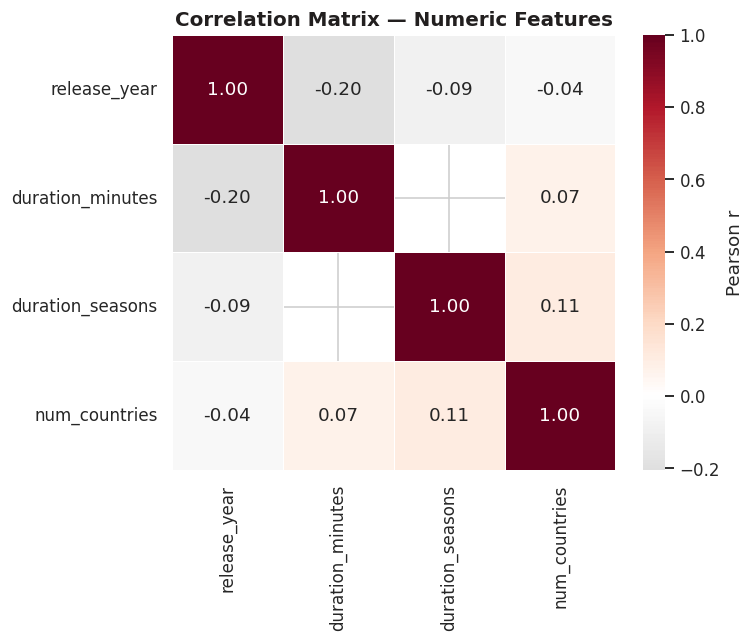

release_year vs duration_minutes: r=-0.192, p=0.0000 (statistically significant at α=0.05)
Insight: movies have gotten slightly shorter over time as the streaming era favors tighter runtimes, though the effect size is small.


In [3]:
corr_df = df[["release_year", "duration_minutes", "duration_seasons", "num_countries"]].copy()
corr_matrix = corr_df.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, cmap="RdGy_r", center=0, ax=ax, fmt=".2f",
            linewidths=0.5, cbar_kws={"label": "Pearson r"})
ax.set_title("Correlation Matrix — Numeric Features", fontsize=13, weight="bold", color=NETFLIX_DARK)
plt.tight_layout()
plt.savefig("../images/11_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

r, p = stats.pearsonr(df["release_year"], df["duration_minutes"].fillna(df["duration_minutes"].median()))
print(f"release_year vs duration_minutes: r={r:.3f}, p={p:.4f} "
      f"({'statistically significant' if p < 0.05 else 'not significant'} at α=0.05)")
print("Insight: movies have gotten slightly shorter over time as the streaming era favors tighter runtimes,"
      " though the effect size is small.")

## 3. Outlier Detection (IQR method)
Applied to movie duration — flags unusually short or extremely long films.

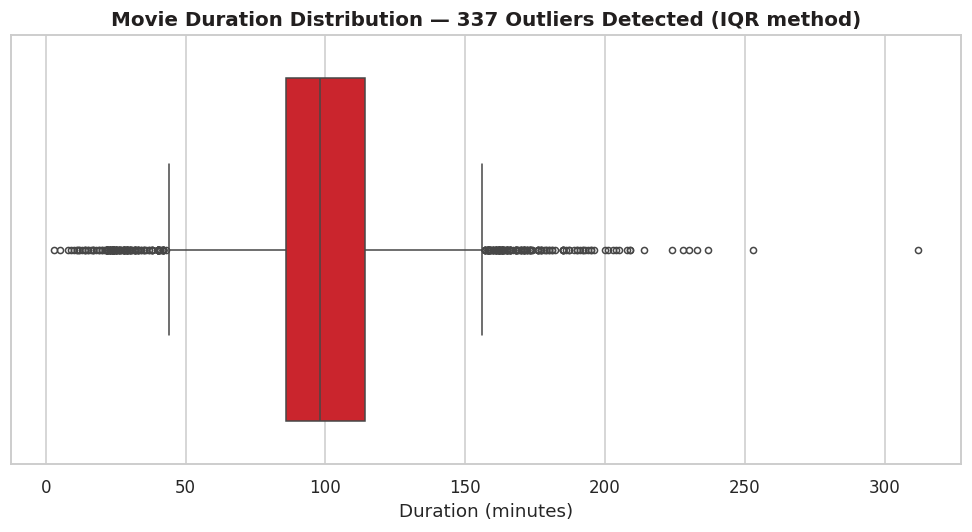

IQR bounds: [44, 156] minutes. 337 outlier movies detected (6.3% of all movies).


,title,duration_minutes,release_year
957,Black Mirror: Bandersnatch,312.0,2018
6849,The School of Mischief,253.0,1973
4489,No Longer kids,237.0,1979
3693,Lock Your Girls In,233.0,1982
5107,Raya and Sakina,230.0,1984
5375,Sangam,228.0,1964
3520,Lagaan,224.0,2001
3194,Jodhaa Akbar,214.0,2008


In [4]:
movie_dur = df[df["type"] == "Movie"]["duration_minutes"].dropna()
Q1, Q3 = movie_dur.quantile(0.25), movie_dur.quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = df[(df["type"] == "Movie") & ((df["duration_minutes"] < lower) | (df["duration_minutes"] > upper))]

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(x=movie_dur, color=NETFLIX_RED, ax=ax, fliersize=4)
ax.set_title(f"Movie Duration Distribution — {len(outliers)} Outliers Detected (IQR method)",
             fontsize=13, weight="bold", color=NETFLIX_DARK)
ax.set_xlabel("Duration (minutes)")
plt.tight_layout()
plt.savefig("../images/12_outlier_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"IQR bounds: [{lower:.0f}, {upper:.0f}] minutes. {len(outliers)} outlier movies detected "
      f"({100*len(outliers)/len(movie_dur):.1f}% of all movies).")
outliers[["title", "duration_minutes", "release_year"]].sort_values("duration_minutes", ascending=False).head(8)

## 4. Genre Popularity Analysis

/tmp/ipykernel_779/3493665800.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="Reds_r", ax=ax)


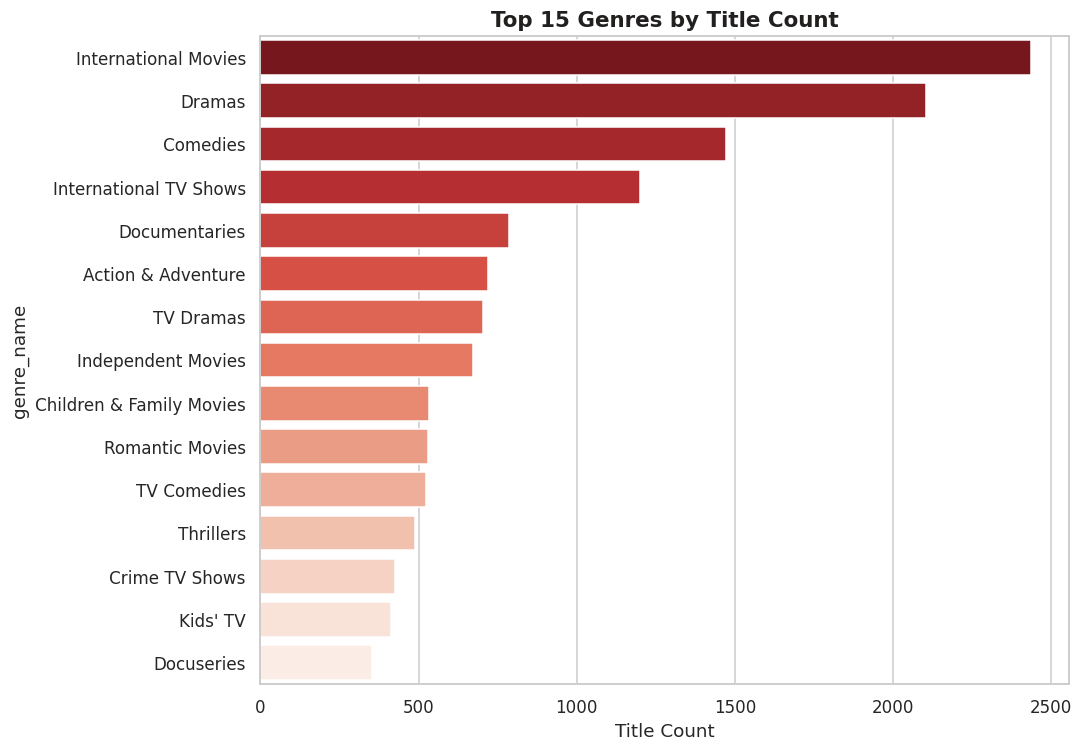

genre_name
International Movies        2436
Dramas                      2105
Comedies                    1471
International TV Shows      1199
Documentaries                786
Action & Adventure           721
TV Dramas                    704
Independent Movies           673
Children & Family Movies     532
Romantic Movies              531
TV Comedies                  525
Thrillers                    490
Crime TV Shows               427
Kids' TV                     414
Docuseries                   353
Name: count, dtype: int64

In [5]:
genre_counts = bridge_genre["genre_name"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 7))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="Reds_r", ax=ax)
ax.set_title("Top 15 Genres by Title Count", fontsize=14, weight="bold", color=NETFLIX_DARK)
ax.set_xlabel("Title Count")
plt.tight_layout()
plt.savefig("../images/13_genre_popularity.png", dpi=150, bbox_inches="tight")
plt.show()
genre_counts

## 5. Country Comparison — content profile radar
Compares the US, India, UK, Japan and South Korea across catalog size,
genre diversity, and average maturity skew.

In [6]:
focus_countries = ["United States", "India", "United Kingdom", "Japan", "South Korea"]
profile_rows = []
for c in focus_countries:
    ids = bridge_country[bridge_country["country_name"] == c]["show_id"]
    sub = df[df["show_id"].isin(ids)]
    genres_for_c = bridge_genre[bridge_genre["show_id"].isin(ids)]
    profile_rows.append({
        "country": c,
        "total_titles": len(sub),
        "pct_movies": (sub["type"] == "Movie").mean() * 100,
        "genre_diversity": genres_for_c["genre_name"].nunique(),
        "pct_mature": (sub["maturity_level"] == "Adults").mean() * 100,
        "avg_movie_duration": sub.loc[sub["type"] == "Movie", "duration_minutes"].mean(),
    })
profile_df = pd.DataFrame(profile_rows).round(1)
profile_df

,country,total_titles,pct_movies,genre_diversity,pct_mature,avg_movie_duration
0,United States,3297,73.7,42,47.7,92.4
1,India,990,92.4,35,25.4,126.3
2,United Kingdom,723,64.6,37,49.4,97.2
3,Japan,287,35.9,34,35.2,96.9
4,South Korea,212,25.9,28,42.5,109.7


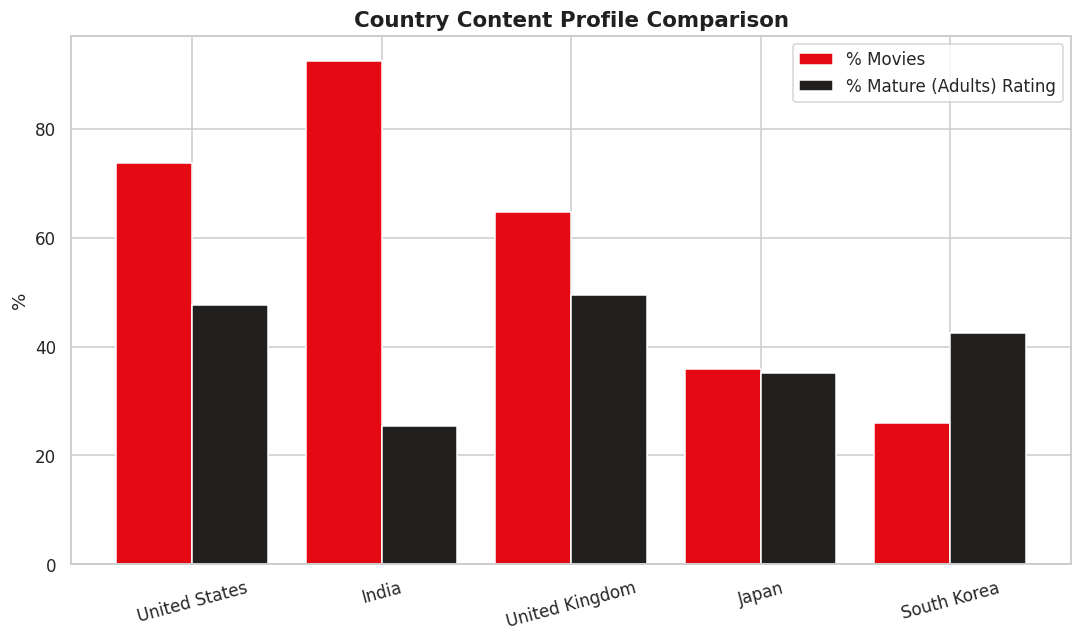

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(focus_countries))
ax.bar(x - 0.2, profile_df["pct_movies"], width=0.4, label="% Movies", color=NETFLIX_RED)
ax.bar(x + 0.2, profile_df["pct_mature"], width=0.4, label="% Mature (Adults) Rating", color=NETFLIX_DARK)
ax.set_xticks(x)
ax.set_xticklabels(focus_countries, rotation=15)
ax.set_ylabel("%")
ax.set_title("Country Content Profile Comparison", fontsize=14, weight="bold", color=NETFLIX_DARK)
ax.legend()
plt.tight_layout()
plt.savefig("../images/14_country_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Time-Series Analysis — cumulative catalog growth

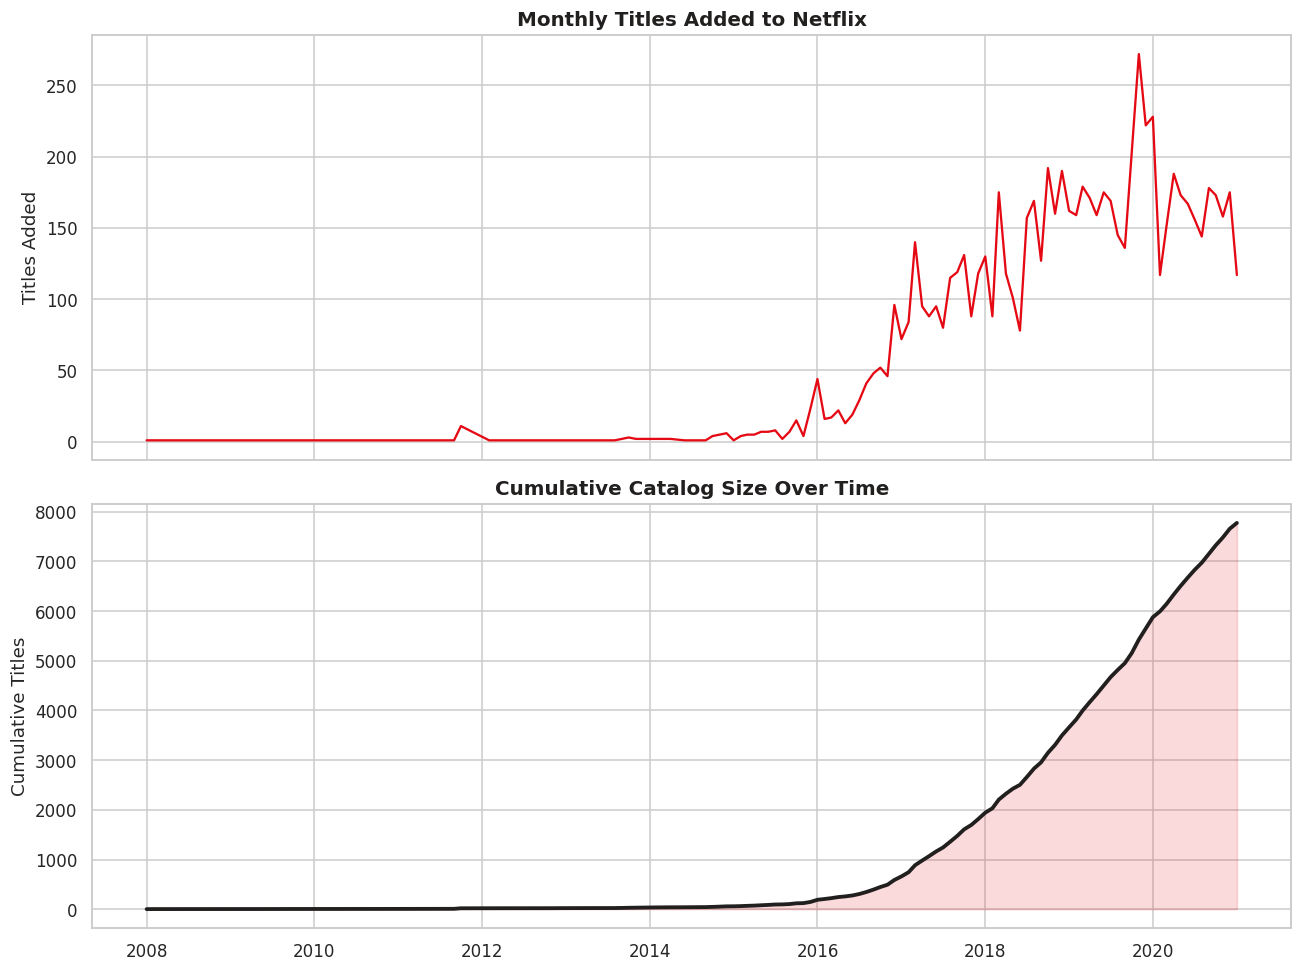

Insight: catalog additions are decelerating in the most recent quarter of available data relative to 6 months prior.


In [8]:
ts = df[df["date_added_parsed"].notna()].copy()
ts["year_month"] = ts["date_added_parsed"].dt.to_period("M")
monthly_adds = ts.groupby("year_month").size()
monthly_adds.index = monthly_adds.index.to_timestamp()
cumulative = monthly_adds.cumsum()

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
axes[0].plot(monthly_adds.index, monthly_adds.values, color=NETFLIX_RED, linewidth=1.5)
axes[0].set_title("Monthly Titles Added to Netflix", fontsize=13, weight="bold", color=NETFLIX_DARK)
axes[0].set_ylabel("Titles Added")

axes[1].plot(cumulative.index, cumulative.values, color=NETFLIX_DARK, linewidth=2.5)
axes[1].fill_between(cumulative.index, cumulative.values, color=NETFLIX_RED, alpha=0.15)
axes[1].set_title("Cumulative Catalog Size Over Time", fontsize=13, weight="bold", color=NETFLIX_DARK)
axes[1].set_ylabel("Cumulative Titles")
plt.tight_layout()
plt.savefig("../images/15_time_series_growth.png", dpi=150, bbox_inches="tight")
plt.show()

# Simple 3-month rolling average trend
rolling = monthly_adds.rolling(3).mean()
recent_trend = "accelerating" if rolling.iloc[-1] > rolling.iloc[-7] else "decelerating"
print(f"Insight: catalog additions are {recent_trend} in the most recent quarter of available data "
      f"relative to 6 months prior.")

## Key Takeaways for Phase 5
- Movie durations are right-skewed with a small set of true long-form
  outliers (concert films, multi-part epics) worth excluding from "typical
  runtime" planning conversations.
- `release_year` and `duration_minutes` show a weak negative correlation —
  modern movies trend slightly shorter, consistent with streaming-era
  pacing.
- Genre popularity is heavily concentrated in International Movies/TV,
  Dramas, and Comedies — the long tail of niche genres is where
  diversification opportunity lives (see Phase 7).
- Country content profiles diverge meaningfully: India is movie-heavy,
  South Korea and Japan are TV-/anime-heavy with high international
  genre tagging, useful for region-specific content investment.